# Quickstart: CHIRPS preliminary and final rainfall

CHIRPS v3 combines satellite and rain-gauge estimates on a 0.05° land grid from 60°S to 60°N. The final archive starts in 1981; the preliminary archive starts in 2025.

Catalog: [preliminary](https://dynamical.org/catalog/ucsb-chc-chirps-analysis-preliminary/) · [final](https://dynamical.org/catalog/ucsb-chc-chirps-analysis-final/).
[UCSB Climate Hazards Center, CHIRPS v3](https://doi.org/10.15780/G2JQ0P), licensed under [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).

In [ ]:
# If running locally, follow README.md for simple dependency installation.
# If using Google Colab, run this cell.
!uv pip install dynamical-catalog cartopy

In [2]:
import os
import dynamical_catalog

# Use staging until CHIRPS is promoted to the production catalog.
os.environ.setdefault("DYNAMICAL_STAC_CATALOG_URL", "https://stac-staging.dynamical.org/catalog.json")
preliminary = dynamical_catalog.open("ucsb-chc-chirps-analysis-preliminary", chunks=None)
final = dynamical_catalog.open("ucsb-chc-chirps-analysis-final", chunks=None)
final

<xarray.Dataset> Size: 1TB
Dimensions:                (time: 16679, latitude: 2400, longitude: 7200)
Coordinates:
  * time                   (time) datetime64[ns] 133kB 1981-01-01 ... 2026-08-31
  * latitude               (latitude) float64 19kB 59.98 59.93 ... -59.93 -59.98
  * longitude              (longitude) float64 58kB -180.0 -179.9 ... 180.0
    spatial_ref            int64 8B ...
Data variables:
    precipitation_surface  (time, latitude, longitude) float32 1TB ...
Attributes:
    dataset_id:          ucsb-chc-chirps-analysis-final
    dataset_version:     0.1.0
    name:                UCSB CHC CHIRPS analysis, final
    description:         Daily precipitation from the Climate Hazards Center ...
    attribution:         UCSB Climate Hazards Center CHIRPS version 3.0 data ...
    license:             CC-BY-4.0
    spatial_domain:      Global land, 60 degrees north to 60 degrees south
    spatial_resolution:  0.05 degrees (~5km)
    time_domain:         1981-01-01 00:00:00 UTC to Present
    time_resolution:     1 day

## Which product reaches closer to today?

[CHC publishes preliminary estimates](https://www.chc.ucsb.edu/data/chirps3) about two days after each five-day period ends. Final estimates arrive monthly, usually in the third week of the following month, with more thoroughly checked gauge inputs.

In [3]:
import pandas as pd

pd.Series(
    {"preliminary": preliminary.time.values[-1], "final": final.time.values[-1]},
    name="Latest stored day",
).to_frame()

,Latest stored day
preliminary,2026-09-10
final,2026-08-31


## How much can daily estimates change?

[Heavy rain affected Odisha and Gangetic West Bengal on 14–15 August 2026](https://mausam.imd.gov.in/Forecast/marquee_data/Press%20Release%2015-08-2026.pdf); compare the August estimates near Kolkata. These catalog products also differ in [daily timing](https://data.chc.ucsb.edu/products/CHIRPS/v3.0/daily/readme.txt): preliminary distributes five-day totals using IMERG rainfall, while final uses ERA5.

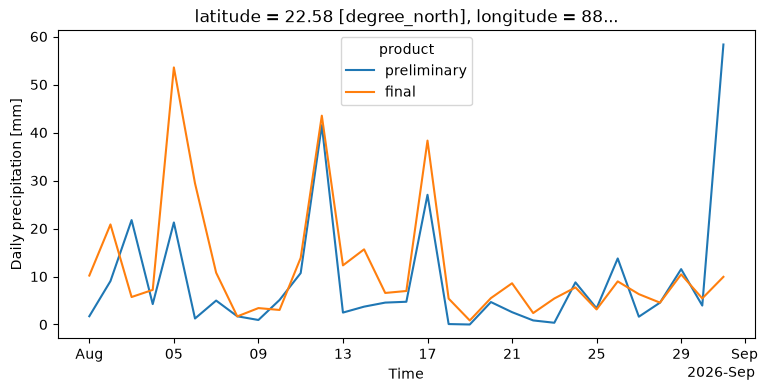

In [4]:
import xarray as xr

point = xr.concat(
    [
        ds["precipitation_surface"]
        .sel(latitude=22.57, longitude=88.36, method="nearest")
        .sel(time=slice("2026-08-01", "2026-08-31"))
        .load()
        for ds in (preliminary, final)
    ],
    dim=pd.Index(["preliminary", "final"], name="product"),
    join="exact",
)
# Rates are in mm/s over the 24 hours starting at each timestamp.
daily = point * 86400
daily.attrs = {"long_name": "Daily precipitation", "units": "mm"}
daily.plot(x="time", hue="product", figsize=(9, 4));

## Do revisions also change five-day totals?

Compare 11–15 August across eastern India. Summing a complete five-day period separates changes in rainfall amount from the daily timing differences.

In [5]:
preliminary_period, final_period = xr.align(
    *[
        ds["precipitation_surface"]
        .sel(time=slice("2026-08-11", "2026-08-15"),
             latitude=slice(25, 19), longitude=slice(83, 89))
        .load()
        for ds in (preliminary, final)
    ],
    join="exact",
)
change = (final_period - preliminary_period).sum("time", skipna=False) * 86400
change.attrs = {"long_name": "Five-day rainfall revision (final − preliminary)", "units": "mm"}

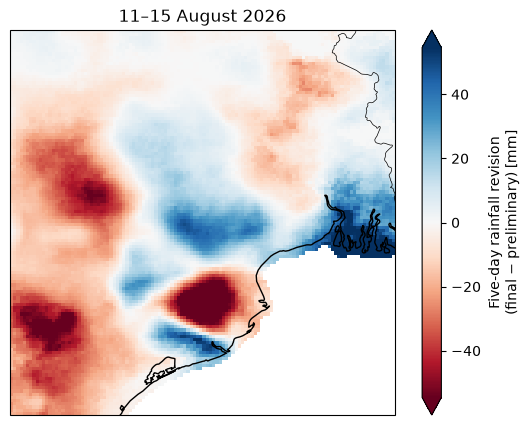

In [6]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5), subplot_kw={"projection": ccrs.PlateCarree()})
change.plot(ax=ax, transform=ccrs.PlateCarree(), cmap="RdBu", center=0, robust=True)
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title("11–15 August 2026");

### Community challenge

How do revisions vary across wet and dry seasons? Would using preliminary estimates change which dry spells cross a drought-monitoring threshold?